In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Recreate the same customer dataset
np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

# Select customer behavior features
features = [
    "Age",
    "Income",
    "Purchase_Amount",
    "Savings",
    "Credit_Score"
]

X = df[features]

# Scale features and recreate the six clusters
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Dataset Shape:", df.shape)
print("\nCustomer Cluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

display(df.head())

Dataset Shape: (100, 7)

Customer Cluster Distribution:
Cluster
0    14
1    18
2    19
3    11
4    17
5    21
Name: count, dtype: int64


,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased,Cluster
0,56,28392,646,16093,393,0,0
1,46,50535,3719,23070,752,1,2
2,32,98603,3411,40777,503,1,5
3,25,72256,2234,21538,517,1,1
4,38,55222,2343,15729,773,1,2


In [2]:
persona_summary = (
    df.groupby("Cluster")
      .agg(
          Customers=("Cluster", "size"),
          Avg_Age=("Age", "mean"),
          Avg_Income=("Income", "mean"),
          Avg_Purchase=("Purchase_Amount", "mean"),
          Avg_Savings=("Savings", "mean"),
          Avg_Credit_Score=("Credit_Score", "mean")
      )
      .round(2)
)

print("Customer Persona Summary:")
display(persona_summary)

Customer Persona Summary:


,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,
0,14,50.86,49435.71,1593.64,22480.00,382.86
1,18,23.72,64498.72,2926.61,20314.83,445.00
2,19,32.42,49662.26,2616.16,15565.26,741.05
3,11,46.91,79434.00,3592.82,10442.82,473.45
4,17,35.71,43442.35,3719.82,39421.41,650.76
5,21,43.48,84902.62,2373.14,32115.43,635.95


In [3]:
persona_names = {
    0: "Mature Value-Conscious Customers",
    1: "Young Emerging Spenders",
    2: "Credit-Strong Customers",
    3: "Affluent Active Spenders",
    4: "High-Savings Active Buyers",
    5: "Affluent Savers"
}

df["Persona"] = df["Cluster"].map(persona_names)

persona_summary["Persona"] = persona_summary.index.map(persona_names)

display(persona_summary)

,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score,Persona
Cluster,,,,,,,
0,14,50.86,49435.71,1593.64,22480.00,382.86,Mature Value-Conscious Customers
1,18,23.72,64498.72,2926.61,20314.83,445.00,Young Emerging Spenders
2,19,32.42,49662.26,2616.16,15565.26,741.05,Credit-Strong Customers
3,11,46.91,79434.00,3592.82,10442.82,473.45,Affluent Active Spenders
4,17,35.71,43442.35,3719.82,39421.41,650.76,High-Savings Active Buyers
5,21,43.48,84902.62,2373.14,32115.43,635.95,Affluent Savers


In [4]:
persona_summary["Customer_Percentage"] = (
    persona_summary["Customers"] / len(df) * 100
).round(2)

purchase_rate = (
    df.groupby("Cluster")["Purchased"]
      .mean()
      .mul(100)
      .round(2)
)

persona_summary["Purchase_Rate_Pct"] = purchase_rate

display(persona_summary)

,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score,Persona,Customer_Percentage,Purchase_Rate_Pct
Cluster,,,,,,,,,
0,14,50.86,49435.71,1593.64,22480.00,382.86,Mature Value-Conscious Customers,14.0,21.43
1,18,23.72,64498.72,2926.61,20314.83,445.00,Young Emerging Spenders,18.0,94.44
2,19,32.42,49662.26,2616.16,15565.26,741.05,Credit-Strong Customers,19.0,63.16
3,11,46.91,79434.00,3592.82,10442.82,473.45,Affluent Active Spenders,11.0,100.00
4,17,35.71,43442.35,3719.82,39421.41,650.76,High-Savings Active Buyers,17.0,94.12
5,21,43.48,84902.62,2373.14,32115.43,635.95,Affluent Savers,21.0,57.14


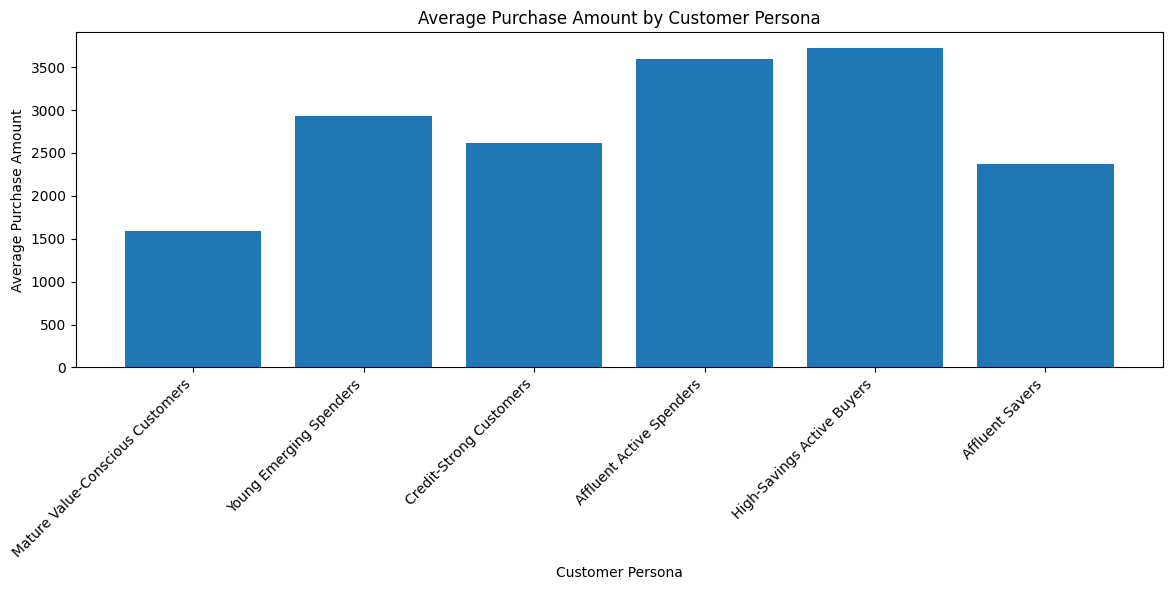

In [5]:
plt.figure(figsize=(12, 6))

plt.bar(
    persona_summary["Persona"],
    persona_summary["Avg_Purchase"]
)

plt.title("Average Purchase Amount by Customer Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Average Purchase Amount")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

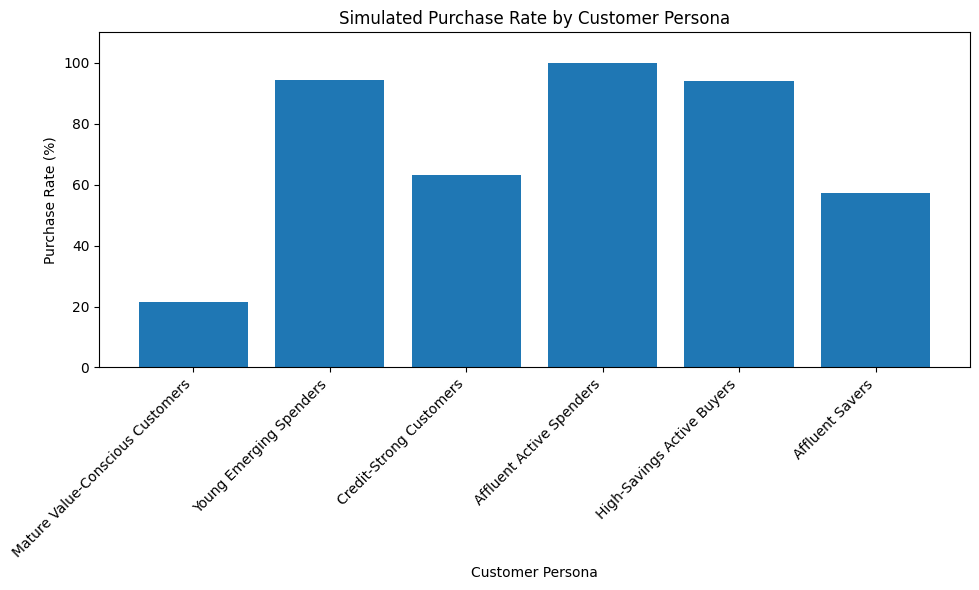

In [6]:
plt.figure(figsize=(10, 6))

plt.bar(
    persona_summary["Persona"],
    persona_summary["Purchase_Rate_Pct"]
)

plt.title("Simulated Purchase Rate by Customer Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [7]:
strategies = {
    "Mature Value-Conscious Customers":
        "Offer value-for-money products, discounts, and loyalty rewards.",

    "Young Emerging Spenders":
        "Use personalized offers, beginner-friendly packages, and referral rewards.",

    "Credit-Strong Customers":
        "Provide premium product options, loyalty benefits, and personalized recommendations.",

    "Affluent Active Spenders":
        "Offer premium experiences, exclusive deals, and complementary products.",

    "High-Savings Active Buyers":
        "Promote premium bundles, reward programs, and savings-linked offers.",

    "Affluent Savers":
        "Introduce investment-oriented products, premium services, and personalized offers."
}

strategy_df = pd.DataFrame({
    "Persona": list(strategies.keys()),
    "Business_Strategy": list(strategies.values())
})

display(strategy_df)

,Persona,Business_Strategy
0,Mature Value-Conscious Customers,"Offer value-for-money products, discounts, and..."
1,Young Emerging Spenders,"Use personalized offers, beginner-friendly pac..."
2,Credit-Strong Customers,"Provide premium product options, loyalty benef..."
3,Affluent Active Spenders,"Offer premium experiences, exclusive deals, an..."
4,High-Savings Active Buyers,"Promote premium bundles, reward programs, and ..."
5,Affluent Savers,"Introduce investment-oriented products, premiu..."


In [8]:
# Save customer persona report
persona_summary.to_csv(
    "day31_customer_persona_report.csv"
)

# Save business strategy recommendations
strategy_df.to_csv(
    "day31_business_strategy_recommendations.csv",
    index=False
)

print("Both Day 31 reports saved successfully!")

Both Day 31 reports saved successfully!
